In [1]:
# # Cell 0) (Optional) Install dependencies
# # Run this only if pyblip is not installed.

# !pip install pyblip cvxpy scikit-learn pandas numpy
# !pip install tqdm
# !Install NumPyro and JAX (for CPU/GPU support)
# !pip install numpyro jax jaxlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# !pip -q install pyblip tqdm scikit-learn pandas numpy

In [4]:
from pathlib import Path
import os, random
PROJECT_DIR = Path("/content/drive/MyDrive/BLiP")
DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "out"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

PROJECT_DIR: /content/drive/MyDrive/BLiP
DATA_DIR: /content/drive/MyDrive/BLiP/data
OUT_DIR: /content/drive/MyDrive/BLiP/out


In [5]:
# Cell 1) Imports + Paths + Config

from __future__ import annotations

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ.setdefault("PYTHONHASHSEED", str(RANDOM_STATE))

# RF settings (final model)
RF_N_ESTIMATORS = 300
RF_MAX_DEPTH = None

# Preprocessing toggle
USE_STANDARDIZE = True  # Fit on TRAIN only, apply to TEST (no leakage)

# Paths: assuming notebook is in BLiP/code/


X_TRAIN_PATH = DATA_DIR / "X_train.csv"
X_TEST_PATH  = DATA_DIR / "X_test.csv"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
Y_TEST_PATH  = DATA_DIR / "y_test.csv"

print("DATA_DIR:", DATA_DIR)
print("Files exist:",
      X_TRAIN_PATH.exists(), X_TEST_PATH.exists(),
      Y_TRAIN_PATH.exists(), Y_TEST_PATH.exists())

DATA_DIR: /content/drive/MyDrive/BLiP/data
Files exist: True True True True


In [6]:
# Cell 2) Load data (GBM) + sanity checks

X_train_df = pd.read_csv(X_TRAIN_PATH)
X_test_df  = pd.read_csv(X_TEST_PATH)

y_train_df = pd.read_csv(Y_TRAIN_PATH)
y_test_df  = pd.read_csv(Y_TEST_PATH)

if y_train_df.shape[1] != 1 or y_test_df.shape[1] != 1:
    raise ValueError(
        f"Expected y_train/y_test to have exactly 1 column, "
        f"got y_train={y_train_df.shape}, y_test={y_test_df.shape}"
    )

y_train = y_train_df.iloc[:, 0].to_numpy().ravel().astype(int)
y_test  = y_test_df.iloc[:, 0].to_numpy().ravel().astype(int)

# Keep feature names
feature_names = list(X_train_df.columns)

# Convert to numpy
X_train = X_train_df.to_numpy(dtype=float)
X_test  = X_test_df.to_numpy(dtype=float)


# --- Force dtypes to match pyblip's Cython expectations (Windows-safe) ---

# y must be int32 / C-int (avoid int64)
y_train = np.asarray(y_train, dtype=np.intc)   # np.intc = C int (usually int32 on Windows)
y_test  = np.asarray(y_test,  dtype=np.intc)

# X must be float64 and C-contiguous
X_train = np.asarray(X_train, dtype=np.float64, order="C")
X_test  = np.asarray(X_test,  dtype=np.float64, order="C")

print("Dtypes check:")
print("  X_train:", X_train.dtype, "C_CONTIGUOUS:", X_train.flags["C_CONTIGUOUS"])
print("  y_train:", y_train.dtype)

print("=== Shapes ===")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\n=== Label check ===")
print("Train positive rate:", y_train.mean())
print("Test  positive rate:", y_test.mean())

# Basic consistency checks
if X_train.shape[1] != X_test.shape[1]:
    raise ValueError("Train/test feature dimension mismatch.")
if len(feature_names) != X_train.shape[1]:
    raise ValueError("Feature name length mismatch.")

Dtypes check:
  X_train: float64 C_CONTIGUOUS: True
  y_train: int32
=== Shapes ===
X_train: (82, 724) y_train: (82,)
X_test : (36, 724) y_test : (36,)

=== Label check ===
Train positive rate: 0.6585365853658537
Test  positive rate: 0.6666666666666666


In [7]:
# Preprocessing toggle
USE_STANDARDIZE = True  # Fit on TRAIN only, apply to TEST (no leakage)

In [8]:
# Cell 3) Preprocess (fit on TRAIN only) -> transform TEST (temporal-safe / no leakage)

if USE_STANDARDIZE:
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_train_pp = scaler.fit_transform(X_train)   # fit on TRAIN only
    X_test_pp  = scaler.transform(X_test)        # transform TEST only
else:
    X_train_pp = X_train.copy()
    X_test_pp  = X_test.copy()
# After preprocessing
X_train_pp = np.asarray(X_train_pp, dtype=np.float64, order="C")
X_test_pp  = np.asarray(X_test_pp,  dtype=np.float64, order="C")

print("USE_STANDARDIZE =", USE_STANDARDIZE)
print("X_train_pp mean (first 5 cols):", X_train_pp[:, :5].mean(axis=0))
print("X_train_pp std  (first 5 cols):", X_train_pp[:, :5].std(axis=0))

USE_STANDARDIZE = True
X_train_pp mean (first 5 cols): [-5.31417728e-17  6.76965259e-17 -4.06179155e-17  2.57246798e-17
 -8.39436921e-17]
X_train_pp std  (first 5 cols): [1. 1. 1. 1. 1.]


In [9]:
# Cell 4) Baseline RF (all features) - evaluate once on TEST

rf_base = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)

rf_base.fit(X_train_pp, y_train)

base_proba = rf_base.predict_proba(X_test_pp)[:, 1]
base_pred  = (base_proba >= 0.5).astype(int)

print("=== Baseline RF (all features) ===")
print("Accuracy:", accuracy_score(y_test, base_pred))
try:
    print("ROC AUC :", roc_auc_score(y_test, base_proba))
except ValueError:
    print("ROC AUC : undefined (only one class present in y_test)")
print("Confusion matrix:\n", confusion_matrix(y_test, base_pred))

=== Baseline RF (all features) ===
Accuracy: 0.6944444444444444
ROC AUC : 0.7031250000000001
Confusion matrix:
 [[ 3  9]
 [ 2 22]]


In [10]:
Q_FDR = 0.2  # target FDR level

In [11]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import numpy as np

# --- MCMC Configuration (Final Professional Settings) ---
N_WARMUP = 1000        # Enough time for the sampler to stabilize
N_SAMPLES_GPU = 1000   # High-quality posterior samples
N_CHAINS_GPU = 1
# Changed filename to avoid using the previous 'diverged' samples
BETAS_PATH = OUT_DIR / "pm_betas_numpyro_final.npy"

# --- Define the Bayesian Lasso Model ---
def bayesian_lasso_model(X, y):
    n_obs, n_features = X.shape

    # Priors
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 10.0))
    lambda_ = numpyro.sample("lambda", dist.HalfCauchy(1.0))

    # Features selection via Laplace prior
    with numpyro.plate("features", n_features):
        betas = numpyro.sample("betas", dist.Laplace(0.0, lambda_))

    logits = alpha + jnp.dot(X, betas)

    with numpyro.plate("data", n_obs):
        numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

# --- Execution Block ---
if BETAS_PATH.exists():
    print(f"Loading pre-computed FINAL betas from: {BETAS_PATH}")
    betas = np.load(BETAS_PATH)
else:
    print(f"🚀 Starting Stabilized GPU MCMC Sampling... (Device: {jax.devices()})")

    X_jax = jnp.array(X_train_pp)
    y_jax = jnp.array(y_train)

    # kernel에 target_accept_prob=0.9를 추가해서 샘플링 안정성을 확보해!
    kernel = NUTS(bayesian_lasso_model, target_accept_prob=0.9)

    mcmc = MCMC(
        kernel,
        num_warmup=N_WARMUP,
        num_samples=N_SAMPLES_GPU,
        num_chains=N_CHAINS_GPU,
        progress_bar=True
    )

    # Start sampling
    mcmc.run(jax.random.PRNGKey(RANDOM_STATE), X=X_jax, y=y_jax)

    # Extract results
    posterior_samples = mcmc.get_samples()
    betas = np.array(posterior_samples['betas'])

    np.save(BETAS_PATH, betas)
    print(f"✅ FINAL Stabilized betas saved to: {BETAS_PATH}")

print(f"Final Posterior Betas Shape: {betas.shape}")

Loading pre-computed FINAL betas from: /content/drive/MyDrive/BLiP/out/pm_betas_numpyro_final.npy
Final Posterior Betas Shape: (1000, 724)


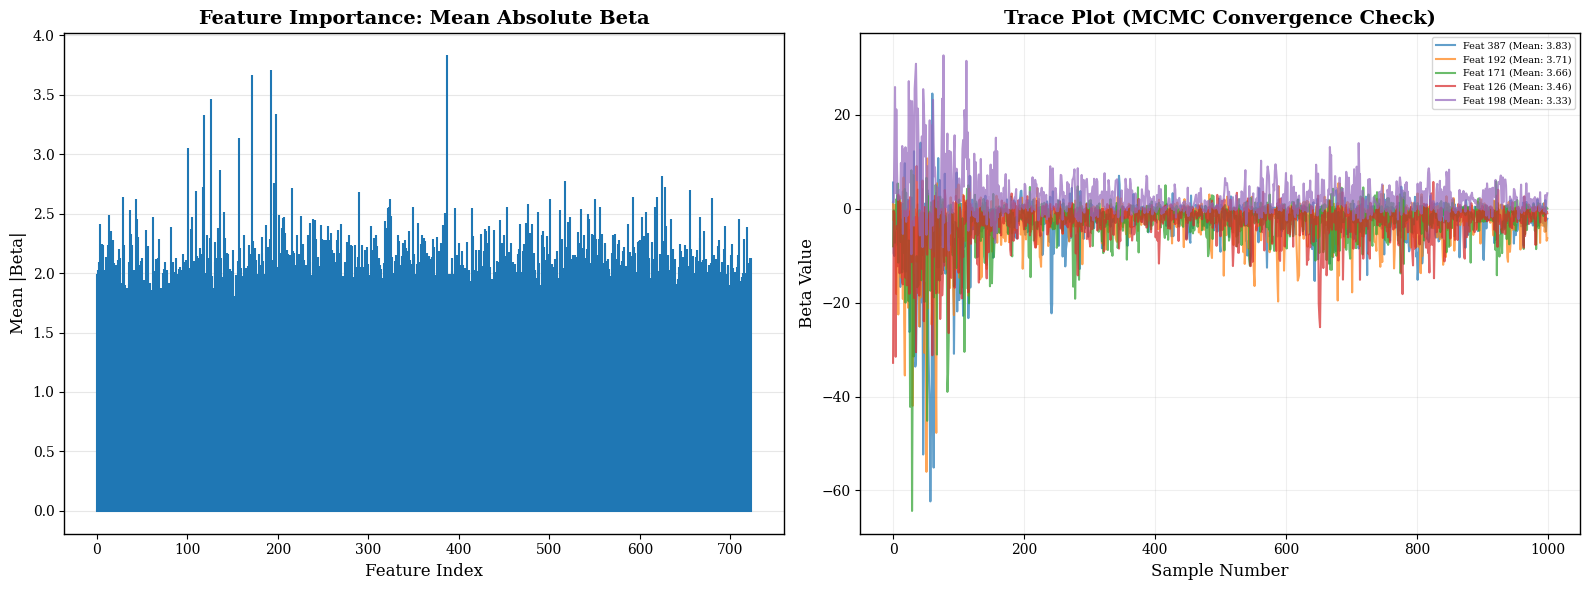

[INFO] 베이지안 PIP 및 Trace Plot 저장 완료:
 - PNG: /content/drive/MyDrive/BLiP/out/figure/Figure_Bayesian_Diagnostics.png
 - PDF: /content/drive/MyDrive/BLiP/out/figure/Figure_Bayesian_Diagnostics.pdf
 - Top 5 Indices: [387 192 171 126 198]


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# 1. 경로 설정 (에러 방지를 위해 Path 객체로 강제 변환)
# ---------------------------------------------------------
# OUT_DIR가 이미 정의되어 있다면 그대로 쓰고, 없으면 새로 정의합니다.
try:
    if not isinstance(OUT_DIR, Path):
        OUT_DIR = Path(OUT_DIR)
except NameError:
    OUT_DIR = Path("BayesianValidation")

FIG_DIR = OUT_DIR / "figure"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 2. 데이터 계산 (PIP 및 중요도 상위 5개 추출)
# ---------------------------------------------------------
# betas: (샘플 수, 피처 수) 형태의 MCMC 사후분포 샘플
small_threshold = 0.5

# PIP (Posterior Inclusion Probability) 계산
pip = np.mean(np.abs(betas) > small_threshold, axis=0)

# 피처별 계수의 절댓값 평균(중요도) 계산
mean_magnitudes = np.mean(np.abs(betas), axis=0)
top_5_idx = np.argsort(mean_magnitudes)[::-1][:5]

# ---------------------------------------------------------
# 3. 시각화 (A: 중요도 분포, B: MCMC 수렴 확인)
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [Plot A] Feature Importance (Mean Magnitude)
# 모든 피처에 대한 계수 크기를 Stem Plot으로 시각화
axes[0].stem(range(len(mean_magnitudes)), mean_magnitudes, markerfmt=' ', basefmt="C0-")
axes[0].set_title("Feature Importance: Mean Absolute Beta", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Feature Index", fontsize=12)
axes[0].set_ylabel("Mean |Beta|", fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# [Plot B] Trace Plot for Top 5 Features (Convergence Check)
# 중요도가 가장 높은 5개 피처가 안정적으로 수렴했는지 확인 (Hairy Caterpillar 확인용)
for i in top_5_idx:
    axes[1].plot(betas[:, i], label=f"Feat {i} (Mean: {mean_magnitudes[i]:.2f})", alpha=0.7)

axes[1].set_title("Trace Plot (MCMC Convergence Check)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Sample Number", fontsize=12)
axes[1].set_ylabel("Beta Value", fontsize=12)
axes[1].legend(loc='upper right', fontsize='x-small', frameon=True)
axes[1].grid(alpha=0.2)

plt.tight_layout()

# ---------------------------------------------------------
# 4. 저장 (FIG_DIR 폴더에 모든 포맷 포함 저장)
# ---------------------------------------------------------
save_path_png = FIG_DIR / "Figure_Bayesian_Diagnostics.png"
save_path_pdf = FIG_DIR / "Figure_Bayesian_Diagnostics.pdf"

plt.savefig(save_path_png, dpi=300, bbox_inches='tight')
plt.savefig(save_path_pdf, bbox_inches='tight')
plt.show()

print(f"[INFO] 베이지안 PIP 및 Trace Plot 저장 완료:")
print(f" - PNG: {save_path_png}")
print(f" - PDF: {save_path_pdf}")
print(f" - Top 5 Indices: {top_5_idx}")

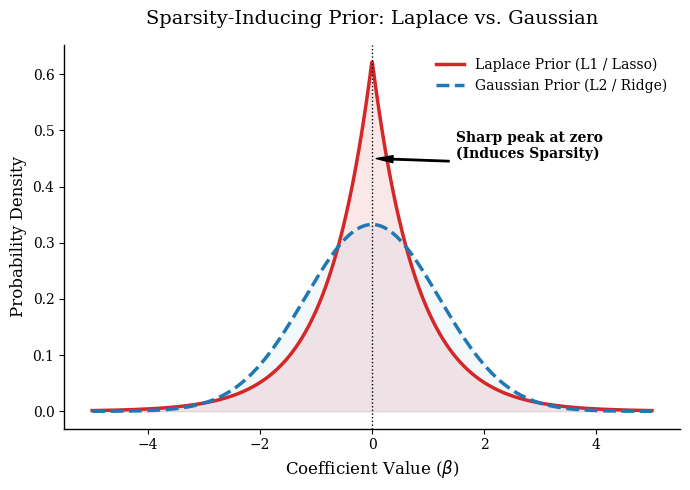

[SUCCESS] 모든 그림이 /content/drive/MyDrive/BLiP/out/figure에 저장되었습니다.


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm
from pathlib import Path
import seaborn as sns

# ---------------------------------------------------------
# 1. 경로 설정 (기존 설정 유지)
# ---------------------------------------------------------
try:
    if not isinstance(OUT_DIR, Path):
        OUT_DIR = Path(OUT_DIR)
except NameError:
    OUT_DIR = Path("BayesianValidation")

FIG_DIR = OUT_DIR / "figure"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

# ---------------------------------------------------------
# 3. [Figure 2] 분포 비교 (Laplace vs Gaussian)
# ---------------------------------------------------------
x = np.linspace(-5, 5, 1000)
l_dist = laplace.pdf(x, loc=0, scale=0.8) # Lasso
g_dist = norm.pdf(x, loc=0, scale=1.2)    # Ridge

fig2 = plt.figure(figsize=(7, 5))

# Plotting
plt.plot(x, l_dist, label='Laplace Prior (L1 / Lasso)', color='#d62728', lw=2.5)
plt.fill_between(x, l_dist, color='#d62728', alpha=0.1)
plt.plot(x, g_dist, label='Gaussian Prior (L2 / Ridge)', color='#1f77b4', lw=2.5, linestyle='--')
plt.fill_between(x, g_dist, color='#1f77b4', alpha=0.05)

# Annotation for Sparsity
plt.axvline(0, color='black', lw=1, ls=':')
plt.annotate('Sharp peak at zero\n(Induces Sparsity)', xy=(0, 0.45), xytext=(1.5, 0.45),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

plt.title("Sparsity-Inducing Prior: Laplace vs. Gaussian", fontsize=14, pad=15)
plt.xlabel(r"Coefficient Value ($\beta$)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(frameon=False)
sns.despine()

fig2.tight_layout()
fig2.savefig(FIG_DIR / "Figure_Laplace_vs_Gaussian_Prior.png", dpi=300, bbox_inches='tight')

plt.show()

print(f"[SUCCESS] 모든 그림이 {FIG_DIR}에 저장되었습니다.")

In [14]:
# from joblib import Parallel, delayed
# import numpy as np
# import matplotlib.pyplot as plt
# from pyblip.blip import BLiP

# # --- 1. 최적화: 샘플 수 줄이기 (속도 5배 향상) ---
# # 1000개를 다 안 쓰고 앞의 200개만 사용해도 민감도 분석 결과는 충분해!
# betas_subset = betas[:200]

# def compute_blip_count(p):
#     try:
#         # 85th percentile 등 동적 임계값 적용
#         thresh = np.percentile(np.abs(betas_subset), p)
#         is_signal = (np.abs(betas_subset) > thresh).astype(float)
#         input_data = is_signal.reshape(-1, is_signal.shape[-1])

#         # BLiP 실행
#         dets = BLiP(samples=input_data, q=0.2, error="fdr", verbose=False, solver="CLARABEL")

#         sel_idx = set()
#         for d in dets:
#             if hasattr(d, 'group'): sel_idx |= set(d.group)
#         return len(sel_idx)
#     except:
#         return 0

# # --- 2. 병렬 실행: 모든 CPU 코어 동원 ---
# print("🚀 Starting Parallel Sensitivity Sweep (CPU Acceleration)...")
# percentiles = np.arange(50, 100, 5)

# # n_jobs=-1 은 내 컴퓨터의 모든 CPU 파워를 다 쓰겠다는 뜻이야
# counts = Parallel(n_jobs=-1)(delayed(compute_blip_count)(p) for p in percentiles)

# # --- 3. 시각화 ---
# plt.figure(figsize=(10, 6))
# plt.plot(percentiles, counts, marker='o', color='royalblue', lw=2)
# if 85 in percentiles:
#     idx_85 = percentiles.tolist().index(85)
#     plt.axvline(x=85, color='red', linestyle='--', label=f'Selected (85th: {counts[idx_85]} feats)')

# plt.title("Fast Sensitivity Sweep (CPU Parallelized)", fontsize=14)
# plt.xlabel("Percentile", fontsize=12)
# plt.ylabel("Number of Selected Features", fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()

In [15]:
# Cell 6) BLiP with Strict Percentile-based Input

import numpy as np
from pyblip.blip import BLiP

np.random.seed(RANDOM_STATE)

# --- 1. Dynamic Signal Definition ---
# Let's define signal as the top 10% of absolute beta magnitudes.
# This forces the model to ignore the 'background noise'.
abs_betas = np.abs(betas)
dynamic_threshold = np.percentile(abs_betas, 90) # Top 15% only

# Create binary signal matrix (1 if important, 0 if noise)
is_signal = (abs_betas > dynamic_threshold).astype(float)
input_samples = is_signal.reshape(-1, is_signal.shape[-1])

print(f"Feeding signal samples to BLiP: {input_samples.shape}")
print(f"Dynamic Threshold (90th percentile): {dynamic_threshold:.4f}")

# --- 2. Run BLiP ---
detections = BLiP(
    samples=input_samples,
    q=Q_FDR,                # 0.1
    error="fdr",
    verbose=False,
    solver="CLARABEL",
    random_state=RANDOM_STATE,
)

# --- 3. Extraction ---
selected_idx = set()
for d in detections:
    grp = getattr(d, "group", None)
    if grp: selected_idx |= set(grp)

selected_idx_sorted = sorted(selected_idx)
selected_features = [feature_names[i] for i in selected_idx_sorted]

print("\n=== Strict BLiP Results ===")
print(f"Detections: {len(detections)}")
print(f"Features Selected: {len(selected_idx_sorted)} / {len(feature_names)}")

Feeding signal samples to BLiP: (1000, 724)
Dynamic Threshold (90th percentile): 4.9110

=== Strict BLiP Results ===
Detections: 3
Features Selected: 72 / 724


In [16]:
# ============================================================
# RF Hyperparameter Tuning Settings (EXACT same as your old code)
# - PARAM_DIST
# - STAGE1_N_ITER
# - cv5
# - tune_rf_for_features()
# ============================================================

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # keep 80 if defined, same as before
RANDOM_STATE  = 42

# EXACT same CV as your old code
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

# EXACT same parameter distribution as your old code
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

def tune_rf_for_features(X_sub, y, label="RF"):
    """
    Tune RF on a given design matrix X_sub (numpy array) and label vector y,
    using EXACT RandomizedSearchCV settings as your old code.
    """
    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0,
    )
    rs.fit(X_sub, y)

    best_params = dict(rs.best_params_)
    # cleanup for direct RF init (same logic)
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

In [17]:
# --- Hyperparameter tuning (same setting) -> refit -> proba ---

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint
import numpy as np

# EXACT tuning setup
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}
N_ITER = 5

X_train_sel = X_train_pp[:, selected_idx_sorted]
X_test_sel  = X_test_pp[:, selected_idx_sorted]

rs = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
    param_distributions=PARAM_DIST,
    n_iter=N_ITER,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1,
    random_state=2042,
    verbose=0
)
rs.fit(X_train_sel, y_train)

best_params = dict(rs.best_params_)
best_params.pop("random_state", None)
best_params.pop("n_jobs", None)
if best_params.get("bootstrap") is False:
    best_params.pop("max_samples", None)

print("[CV] best AUC:", rs.best_score_)
print("[CV] best params:", best_params)

# refit with tuned hyperparams
rf_final = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
rf_final.fit(X_train_sel, y_train)

train_proba = rf_final.predict_proba(X_train_sel)[:, 1]
test_proba  = rf_final.predict_proba(X_test_sel)[:, 1]

[CV] best AUC: 0.8133333333333332
[CV] best params: {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 0.5, 'max_samples': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 364}


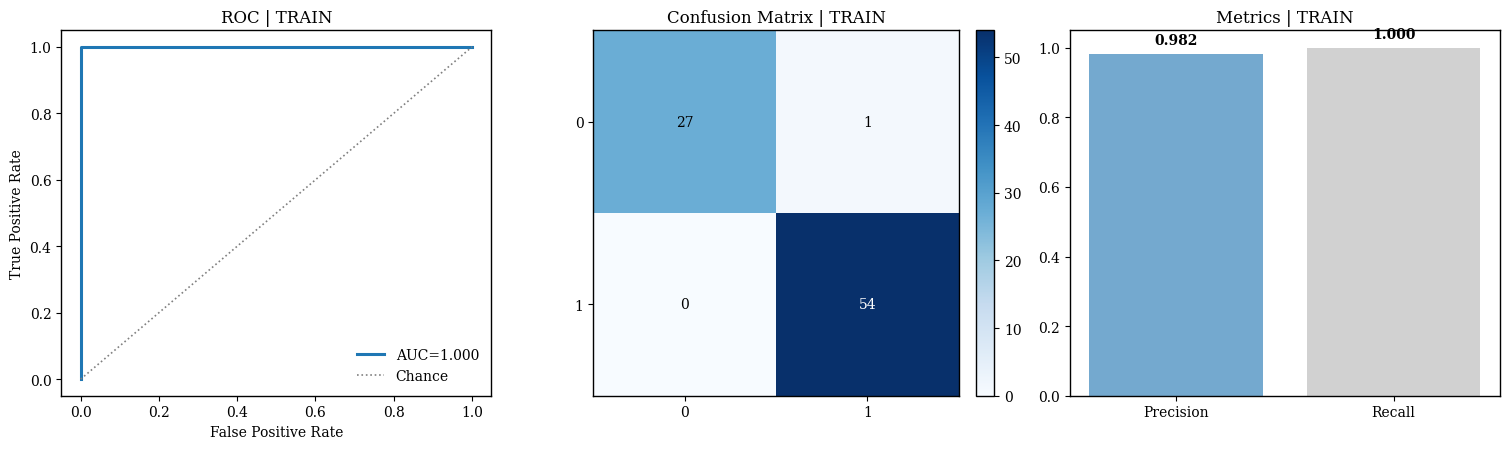

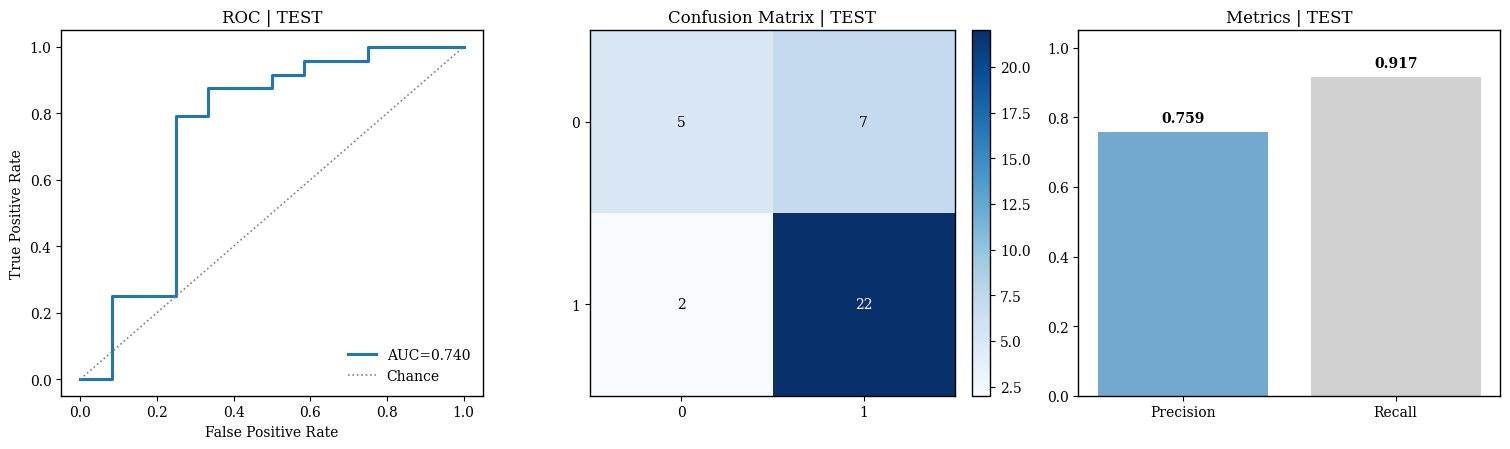

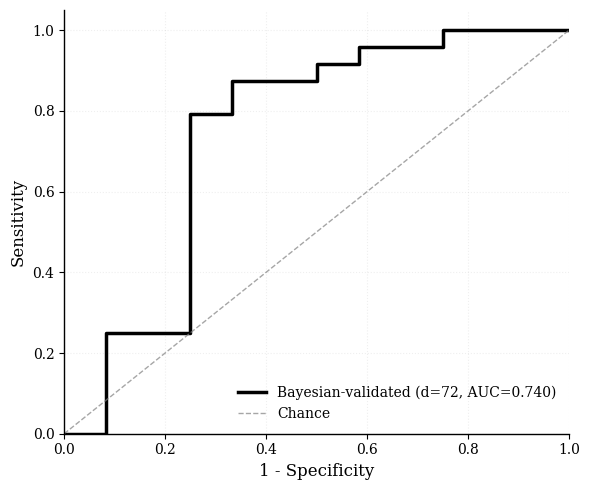

[SAVED] Publication ROC: /content/drive/MyDrive/BLiP/out/figure/Figure_ROC_Bayesian_Final_Publication.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix,
    precision_score, recall_score
)

# ---------------------------------------------------------
# 1. 경로 설정 (Path 객체 사용으로 에러 방지)
# ---------------------------------------------------------
# OUT_DIR가 이미 정의되어 있다고 가정합니다.
# 만약 정의되지 않았다면 아래 주석을 해제하세요.
# OUT_DIR = Path("BayesianValidation")

FIG_DIR = OUT_DIR / "figure"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 2. Cell 7에서 정의한 패널 플롯 함수 (동일 경로 저장)
# ---------------------------------------------------------
def plot_binary_panel(y_true, proba, tag, threshold=0.5, save_dir=FIG_DIR):
    auc = roc_auc_score(y_true, proba)
    fpr, tpr, _ = roc_curve(y_true, proba)

    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec  = recall_score(y_true, pred, zero_division=0)

    # 3-panel figure
    fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.6))

    # (A) ROC
    axes[0].plot(fpr, tpr, lw=2.2, label=f"AUC={auc:.3f}")
    axes[0].plot([0, 1], [0, 1], ls=":", lw=1.2, color="gray", label="Chance")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC | {tag}")
    axes[0].legend(frameon=False, loc="lower right")

    # (B) Confusion Matrix
    im = axes[1].imshow(cm, interpolation="nearest", cmap="Blues")
    axes[1].set_title(f"Confusion Matrix | {tag}")
    axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # (C) Precision/Recall
    axes[2].bar(["Precision", "Recall"], [prec, rec], color=["#74a9cf", "#d1d1d1"])
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title(f"Metrics | {tag}")
    axes[2].text(0, prec + 0.02, f"{prec:.3f}", ha="center", va="bottom", fontweight="bold")
    axes[2].text(1, rec + 0.02, f"{rec:.3f}", ha="center", va="bottom", fontweight="bold")

    fig.tight_layout()

    # 파일명 정제 및 저장
    clean_tag = tag.replace(' ', '_').replace('|','').replace('(', '').replace(')', '')
    stem = f"blip_rf_panel_{clean_tag.lower()}"
    fig.savefig(save_dir / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---------------------------------------------------------
# 3. 논문용 클린 ROC 플롯 함수 (d=74 포함)
# ---------------------------------------------------------
def plot_publication_roc(y_true, proba, n_feats, save_dir=FIG_DIR):
    auc = roc_auc_score(y_true, proba)
    fpr, tpr, _ = roc_curve(y_true, proba)

    plt.figure(figsize=(6, 5))
    plt.rcParams['font.family'] = 'serif'

    # 메인 검정 곡선
    plt.plot(fpr, tpr, color="black", lw=2.5,
             label=f"Bayesian-validated (d={n_feats}, AUC={auc:.3f})")

    # Chance line
    plt.plot([0, 1], [0, 1], color='gray', lw=1.0, ls='--', alpha=0.7, label="Chance")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("1 - Specificity", fontsize=12)
    plt.ylabel("Sensitivity", fontsize=12)
    plt.legend(loc="lower right", fontsize=10, frameon=False)
    plt.grid(alpha=0.2, ls=':')
    sns.despine()
    plt.tight_layout()

    # 저장
    out_path = save_dir / "Figure_ROC_Bayesian_Final_Publication.png"
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] Publication ROC: {out_path}")

# ---------------------------------------------------------
# 4. 실행
# ---------------------------------------------------------
# (1) 기존 패널 플롯 실행 (Train/Test)
plot_binary_panel(y_train, train_proba, tag="TRAIN")
plot_binary_panel(y_test, test_proba, tag="TEST")

# (2) 논문용 클린 ROC 실행 (d=74 반영)
# selected_idx_sorted가 이전 셀에서 정의되어 있어야 합니다.
n_feats = len(selected_idx_sorted)
plot_publication_roc(y_test, test_proba, n_feats=n_feats)

In [21]:
from sklearn.metrics import roc_auc_score

train_cv_auc = rs.best_score_
train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, test_proba)

print(f"Train CV AUC: {train_cv_auc:.4f}")
print(f"Train AUC:    {train_auc:.4f}")
print(f"Test AUC:     {test_auc:.4f}")

Train CV AUC: 0.8133
Train AUC:    1.0000
Test AUC:     0.7396


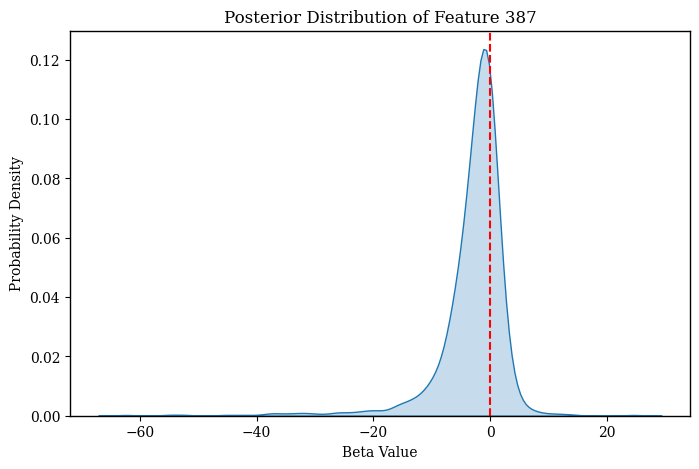

In [19]:
import seaborn as sns

# 상위 5개 변수 인덱스
top_idx = top_5_idx[0] # 예시로 가장 높은 놈 하나만

plt.figure(figsize=(8, 5))
sns.kdeplot(betas[:, top_idx], fill=True)
plt.axvline(x=0, color='red', linestyle='--')
plt.title(f"Posterior Distribution of Feature {top_idx}")
plt.xlabel("Beta Value")
plt.ylabel("Probability Density")
plt.show()